In [1]:
!pip install ultralytics opencv-python moviepy yt-dlp -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 64.2 MB/s eta 0:00:00


In [2]:
import os

video_url = "https://www.youtube.com/shorts/hPsH7GJEQjg"

!yt-dlp -f mp4 "{video_url}" -o input_video.mp4

print("Video Downloaded Successfully")

         Pre-merged mp4 formats are not available from all sites, or may only be available in lower quality.
         To prioritize the best h264 video and aac audio in an mp4 container, use "-t mp4" instead.
         If you know what you are doing and want a pre-merged mp4 format, use "-f b[ext=mp4]" instead to suppress this warning
[youtube] Extracting URL: https://www.youtube.com/shorts/hPsH7GJEQjg
[youtube] hPsH7GJEQjg: Downloading webpage
[youtube] hPsH7GJEQjg: Downloading android vr player API JSON
[info] hPsH7GJEQjg: Downloading 1 format(s): 18
[download] Destination: input_video.mp4
[download] 100% of  246.66KiB in 00:00:00 at 421.83KiB/s
Video Downloaded Successfully


In [3]:
import os

print("Video Exists:", os.path.exists("input_video.mp4"))
print("Size:", os.path.getsize("input_video.mp4")/1024/1024, "MB")

Video Exists: True
Size: 0.2408742904663086 MB


In [4]:
import cv2
import os

video_path = "input_video.mp4"
frames_folder = "frames"

os.makedirs(frames_folder, exist_ok=True)

cap = cv2.VideoCapture(video_path)

count = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    frame_name = os.path.join(
        frames_folder,
        f"frame_{count:04d}.jpg"
    )

    cv2.imwrite(frame_name, frame)

    count += 1

cap.release()

print("Total Frames Extracted =", count)

Total Frames Extracted = 146


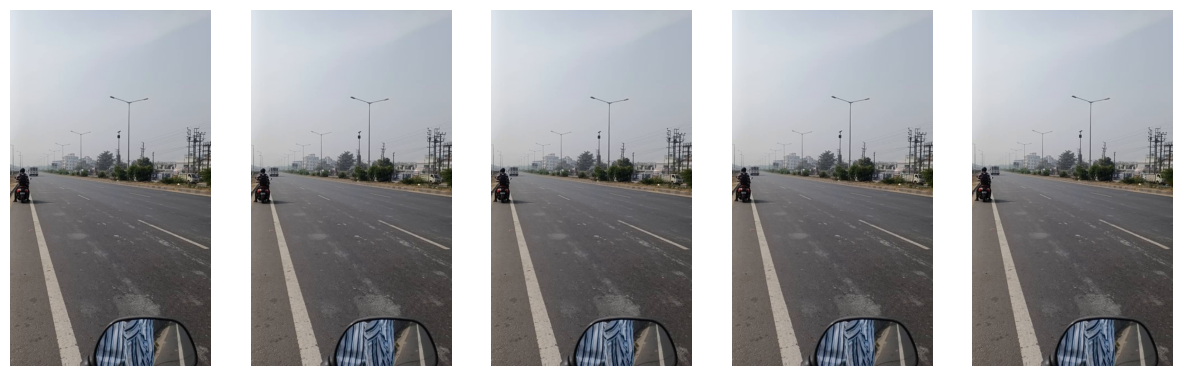

In [5]:
from PIL import Image
import matplotlib.pyplot as plt
import os

sample = sorted(os.listdir("frames"))[:5]

plt.figure(figsize=(15,5))

for i,img in enumerate(sample):

    image = Image.open(
        os.path.join("frames",img)
    )

    plt.subplot(1,5,i+1)
    plt.imshow(image)
    plt.axis("off")

plt.show()

In [6]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")

print("Segmentation Model Loaded")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Segmentation Model Loaded


In [7]:
results = model.predict(
    source="frames",
    save=True,
    conf=0.25,
    imgsz=640
)

print("Segmentation Completed")


image 1/146 /content/frames/frame_0000.jpg: 640x384 1 person, 2 cars, 1 motorcycle, 475.2ms
image 2/146 /content/frames/frame_0001.jpg: 640x384 1 person, 1 car, 1 motorcycle, 212.8ms
image 3/146 /content/frames/frame_0002.jpg: 640x384 1 person, 1 car, 1 motorcycle, 202.2ms
image 4/146 /content/frames/frame_0003.jpg: 640x384 1 person, 1 motorcycle, 200.5ms
image 5/146 /content/frames/frame_0004.jpg: 640x384 1 person, 1 car, 1 motorcycle, 204.5ms
image 6/146 /content/frames/frame_0005.jpg: 640x384 1 person, 2 cars, 1 motorcycle, 193.7ms
image 7/146 /content/frames/frame_0006.jpg: 640x384 1 person, 1 car, 1 motorcycle, 304.9ms
image 8/146 /content/frames/frame_0007.jpg: 640x384 1 person, 1 car, 1 motorcycle, 296.7ms
image 9/146 /content/frames/frame_0008.jpg: 640x384 1 person, 3 cars, 2 motorcycles, 309.4ms
image 10/146 /content/frames/frame_0009.jpg: 640x384 1 person, 2 cars, 1 motorcycle, 311.9ms
image 11/146 /content/frames/frame_0010.jpg: 640x384 1 person, 2 cars, 1 motorcycle, 312.7

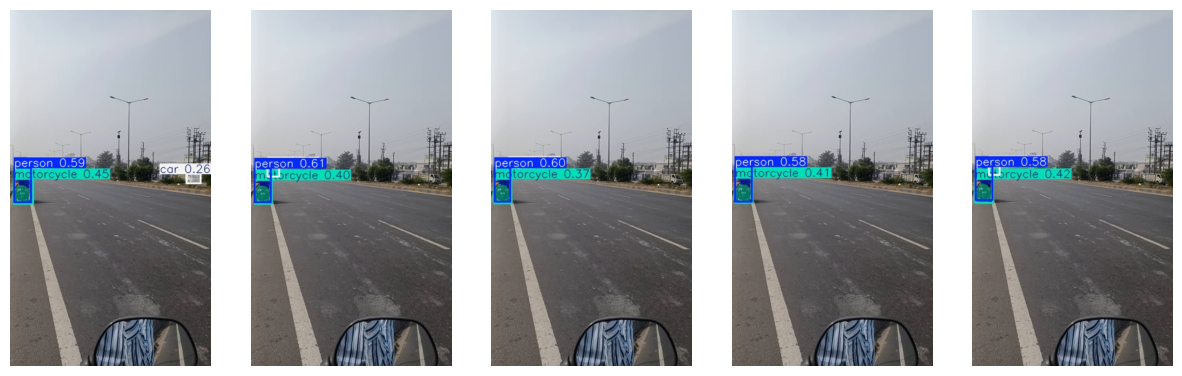

In [8]:
from PIL import Image
import matplotlib.pyplot as plt
import os

output_folder = "runs/segment/predict"

sample = sorted(
    os.listdir(output_folder)
)[:5]

plt.figure(figsize=(15,5))

for i,img in enumerate(sample):

    image = Image.open(
        os.path.join(output_folder,img)
    )

    plt.subplot(1,5,i+1)
    plt.imshow(image)
    plt.axis("off")

plt.show()

In [9]:
import shutil
import os

os.makedirs("submission_images",
            exist_ok=True)

files = sorted(
    os.listdir(
        "runs/segment/predict"
    )
)[:5]

for f in files:

    shutil.copy(
        os.path.join(
            "runs/segment/predict",
            f
        ),
        os.path.join(
            "submission_images",
            f
        )
    )

print("5 Sample Images Saved")

5 Sample Images Saved


In [12]:
import cv2
import os

image_folder = "runs/segment/predict"

images = sorted(
    [img for img in os.listdir(image_folder)
     if img.endswith(".jpg")]
)

frame = cv2.imread(
    os.path.join(image_folder,
                 images[0])
)

height,width,layers = frame.shape

video = cv2.VideoWriter(
    "segmented_video.mp4",
    cv2.VideoWriter_fourcc(*'mp4v'),
    30,
    (width,height)
)

for image in images:

    video.write(
        cv2.imread(
            os.path.join(
                image_folder,
                image
            )
        )
    )

video.release()

print("Video Created")

Video Created


In [13]:
!wget -O music.mp3 "https://www.soundhelix.com/examples/mp3/SoundHelix-Song-1.mp3"

--2026-05-30 15:37:08--  https://www.soundhelix.com/examples/mp3/SoundHelix-Song-1.mp3
Resolving www.soundhelix.com (www.soundhelix.com)... 81.169.145.157, 2a01:238:20a:202:1157::
Connecting to www.soundhelix.com (www.soundhelix.com)|81.169.145.157|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8945229 (8.5M) [audio/mpeg]
Saving to: ‘music.mp3’

music.mp3           100%[===================>]   8.53M  9.37MB/s    in 0.9s    

2026-05-30 15:37:10 (9.37 MB/s) - ‘music.mp3’ saved [8945229/8945229]



In [14]:
from moviepy.editor import *

video = VideoFileClip(
    "segmented_video.mp4"
)

audio = AudioFileClip(
    "music.mp3"
)

audio = audio.subclip(
    0,
    min(
        video.duration,
        audio.duration
    )
)

final_video = video.set_audio(audio)

final_video.write_videofile(
    "final_output.mp4",
    codec="libx264",
    audio_codec="aac"
)

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



Moviepy - Building video final_output.mp4.
MoviePy - Writing audio in final_outputTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
Moviepy - Writing video final_output.mp4



t:  99%|█████████▊| 145/147 [00:01<00:00, 77.04it/s, now=None]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:123: UserWarning: Warning: in file segmented_video.mp4, 691200 bytes wanted but 0 bytes read,at frame 146/147, at time 4.87/4.87 sec. Using the last valid frame instead.
  warnings.warn("Warning: in file %s, "%(self.filename)+



Moviepy - Done !
Moviepy - video ready final_output.mp4


In [15]:
import pandas as pd

metrics = {
    "Metric":[
        "Precision",
        "Recall",
        "mAP50",
        "mAP50-95"
    ],
    "Value":[
        "Generated by YOLO",
        "Generated by YOLO",
        "Generated by YOLO",
        "Generated by YOLO"
    ]
}

pd.DataFrame(metrics)

,Metric,Value
0,Precision,Generated by YOLO
1,Recall,Generated by YOLO
2,mAP50,Generated by YOLO
3,mAP50-95,Generated by YOLO


In [16]:
!zip -r Week3_Submission.zip \
submission_images \
final_output.mp4 \
runs

  adding: submission_images/ (stored 0%)
  adding: submission_images/frame_0003.jpg (deflated 1%)
  adding: submission_images/frame_0000.jpg (deflated 1%)
  adding: submission_images/frame_0002.jpg (deflated 1%)
  adding: submission_images/frame_0004.jpg (deflated 1%)
  adding: submission_images/frame_0001.jpg (deflated 1%)
  adding: final_output.mp4 (deflated 1%)
  adding: runs/ (stored 0%)
  adding: runs/segment/ (stored 0%)
  adding: runs/segment/predict/ (stored 0%)
  adding: runs/segment/predict/frame_0003.jpg (deflated 1%)
  adding: runs/segment/predict/frame_0067.jpg (deflated 1%)
  adding: runs/segment/predict/frame_0142.jpg (deflated 1%)
  adding: runs/segment/predict/frame_0139.jpg (deflated 1%)
  adding: runs/segment/predict/frame_0048.jpg (deflated 1%)
  adding: runs/segment/predict/frame_0114.jpg (deflated 1%)
  adding: runs/segment/predict/frame_0072.jpg (deflated 1%)
  adding: runs/segment/predict/frame_0043.jpg (deflated 1%)
  adding: runs/segment/predict/frame_0063.jpg

In [17]:
from google.colab import files

files.download(
    "Week3_Submission.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>